# Module 1: Spatial Data Basics

Introduction to `GeoPandas` and spatial analysis in Python. This module covers how to handle data with physical location components.

### 1.1 Vector vs. Raster Data
- **Vector Data**: Represented by coordinates (X, Y). Includes Points (cities), Lines (rivers), and Polygons (countries).
- **Raster Data**: Represented by a grid of cells/pixels (satellite imagery).

### 1.2 Coordinate Reference Systems (CRS)
A CRS defines how the 2D surface of a map relates to real-world locations on the 3D Earth. Common ones include:
- **WGS84 (EPSG:4326)**: Latitude/Longitude (degrees).
- **UTM (Projected)**: Meters, better for accurate distance measurements.

### Geometry Types Mapping
```mermaid
graph LR
    G[Geospatial Data] --> V[Vector]
    G --> R[Raster]
    V --> P1[Point]
    V --> P2[Polyline]
    V --> P3[Polygon]
```


In [1]:
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

print(f"GeoPandas version: {gpd.__version__}")

GeoPandas version: 1.1.2


## 2. Reading Spatial Data
In GeoPandas 1.0+, the built-in datasets have moved to the `geodatasets` package. We will use the NYC neighborhoods dataset from the `geoda` collection.

In [2]:
# Load NYC neighborhoods dataset using geodatasets
nyc = gpd.read_file(geodatasets.get_path('geoda.nyc_neighborhoods'))
print(f"Columns: {nyc.columns.tolist()[-10:]}") # Print last 10 columns for inspection
nyc.head()

Columns: ['boroname', 'popdty', 'ntacode', 'medianinco', 'medianagem', 'medianagef', 'medianage', 'HHsize', 'gini', 'geometry']


,UEMPRATE,cartodb_id,borocode,withssi,withsocial,withpubass,struggling,profession,popunemplo,poptot,...,boroname,popdty,ntacode,medianinco,medianagem,medianagef,medianage,HHsize,gini,geometry
0,0.095785,1,3,652,5067,277,6421,889,2225,48351,...,Brooklyn,497498.701,BK45,1520979,663.3,777.1,722.6,2.96421052631579,0.386315789473684,"POLYGON ((-73.91716 40.63173, -73.91722 40.631..."
1,0.090011,2,3,2089,7132,1016,10981,1075,2652,61584,...,Brooklyn,589296.926,BK17,1054259,791.4,868.5,827.6,2.46578947368421,0.448089473684211,"POLYGON ((-73.91809 40.58657, -73.91813 40.586..."
2,0.130393,3,3,3231,8847,2891,21235,712,6483,100130,...,Brooklyn,1506628.84,BK61,980637,863.1,983.9,923.8,2.42925925925926,0.473666666666667,"POLYGON ((-73.92165 40.67887, -73.92171 40.678..."
3,0.086633,4,3,1103,3508,553,7188,475,1709,33155,...,Brooklyn,468975.876,BK90,519058,333.6,350.1,341.3,2.189,0.44139,"POLYGON ((-73.92406 40.71411, -73.92404 40.714..."
4,0.099184,5,4,326,2229,132,5307,187,1276,24199,...,Queens,125384.135,QN23,354073,219,246.3,232.4,2.95666666666667,0.413133333333333,"MULTIPOLYGON (((-73.86788 40.78736, -73.86803 ..."


## 3. Basic Spatial Plotting
We can plot the neighborhoods and color them by the borough name (the column is named `boroname`).

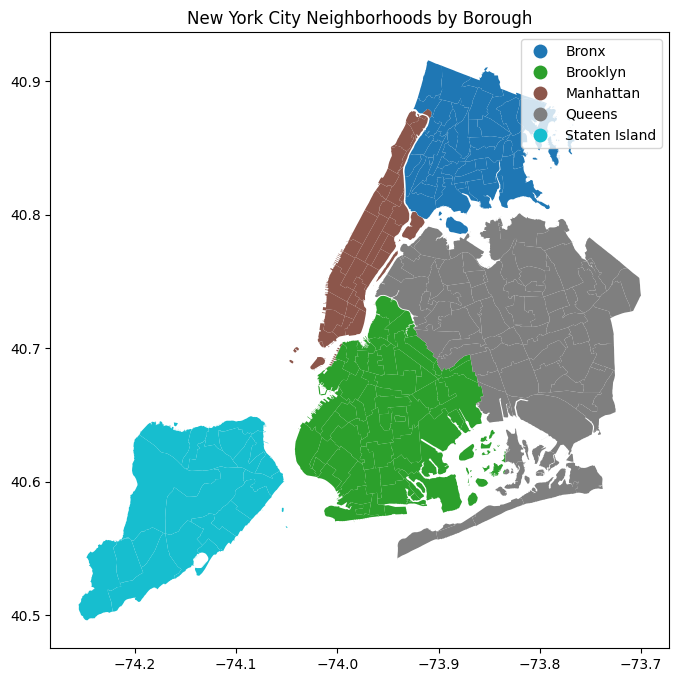

In [3]:
nyc.plot(column='boroname', legend=True, figsize=(12, 8))
plt.title("New York City Neighborhoods by Borough")
plt.show()

## 4. Coordinate Reference Systems (CRS)
CRS is crucial for spatial analysis. Let's check the CRS of our NYC data.

Current CRS: EPSG:4326


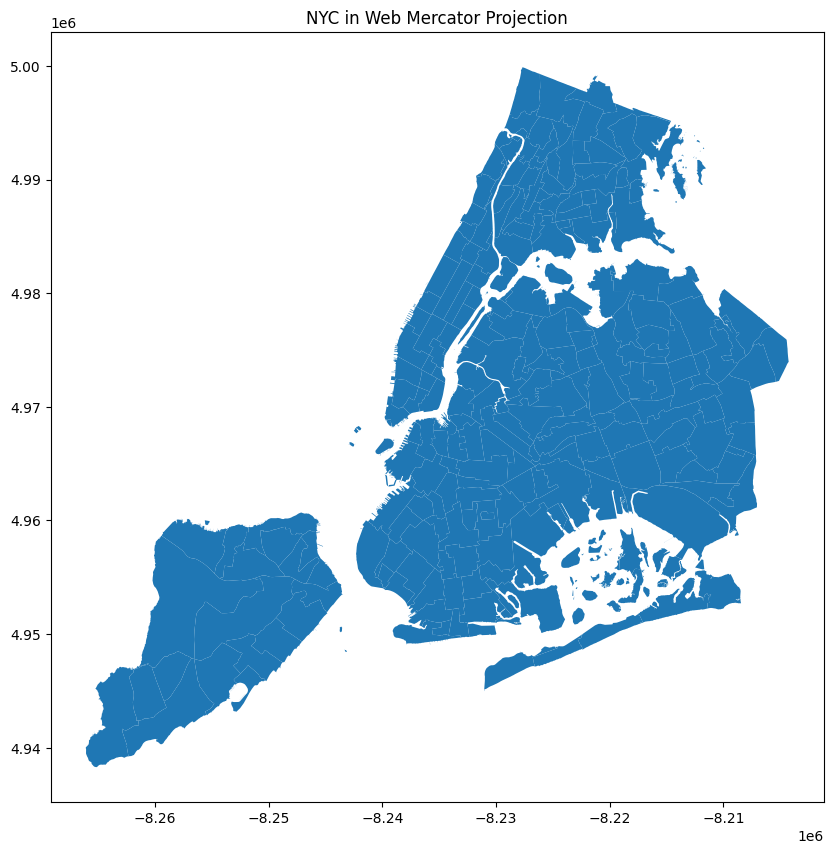

In [4]:
print(f"Current CRS: {nyc.crs}")

# Re-project to a different CRS (e.g., Mercator)
nyc_mercator = nyc.to_crs("EPSG:3857")
nyc_mercator.plot(figsize=(10, 10))
plt.title("NYC in Web Mercator Projection")
plt.show()